***This file shows heatmaps of eye data and other graphs and graphics***

*Data is gathered from the folder "../logs/"*

In [48]:
import os
import glob
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp

*Heatmap of fixation locations*
* One heatmap for each section, aggregated across participants

Found 26 eye_events.csv files
Read 113,497 rows total
Plotting event type: fixation
Min points per heatmap: 50
Categories with heatmaps: 12


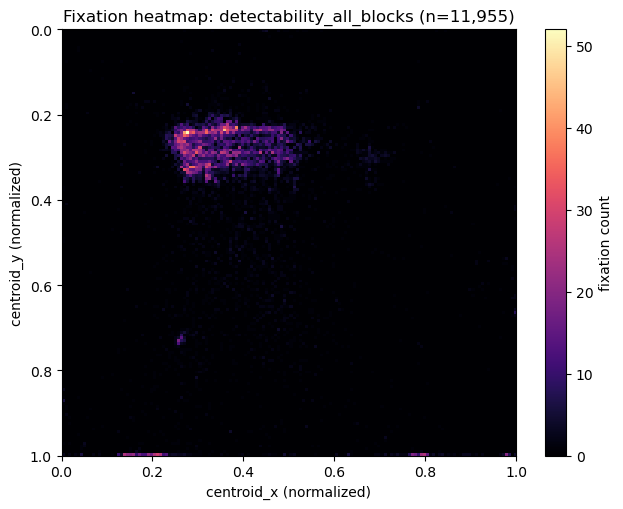

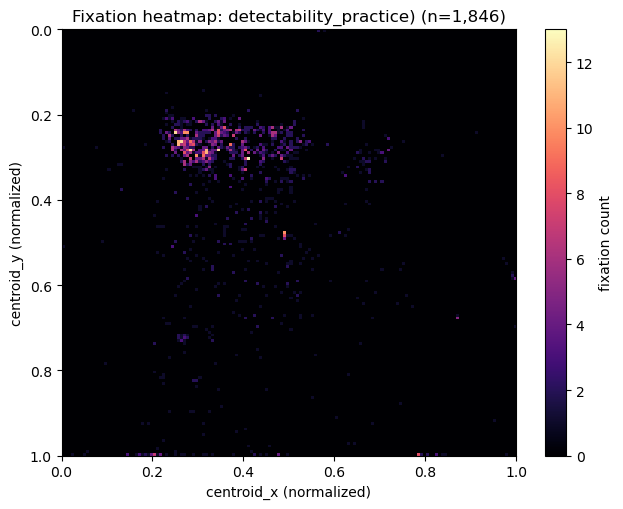

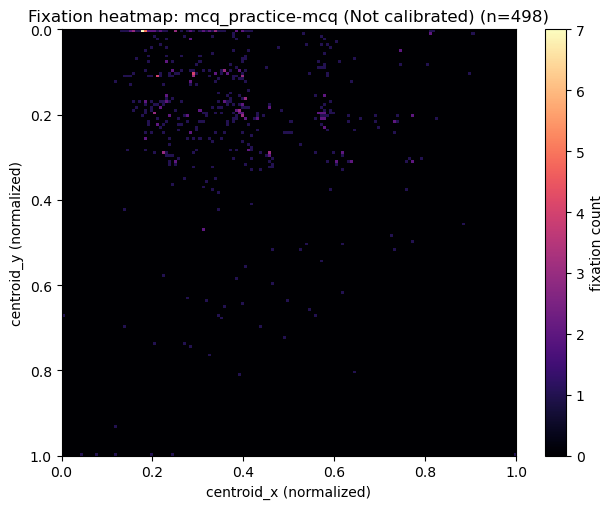

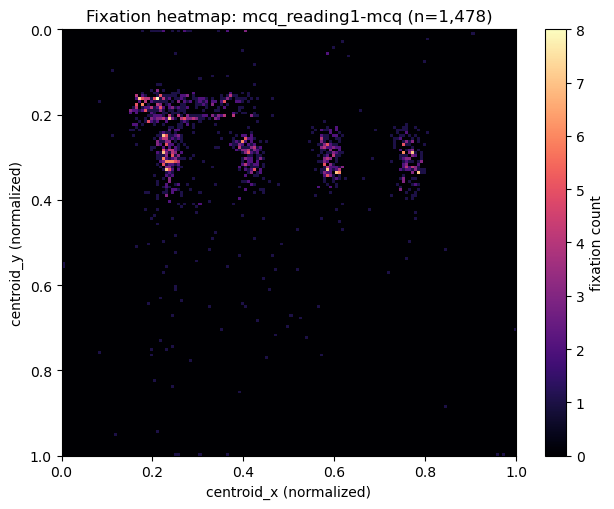

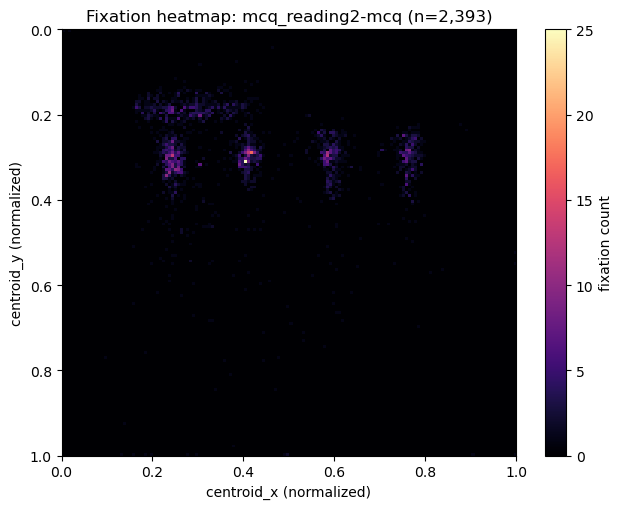

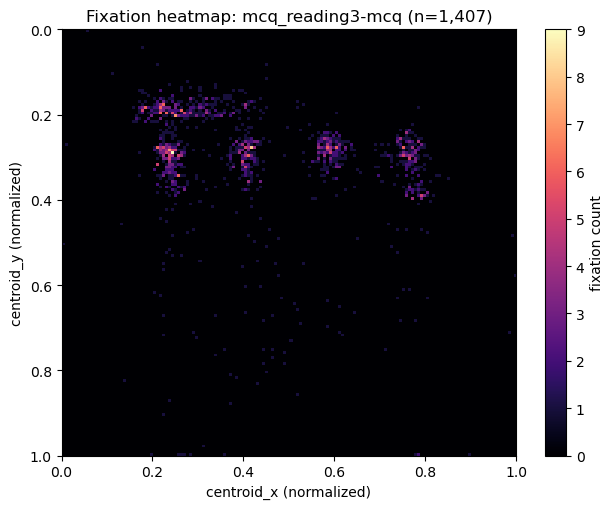

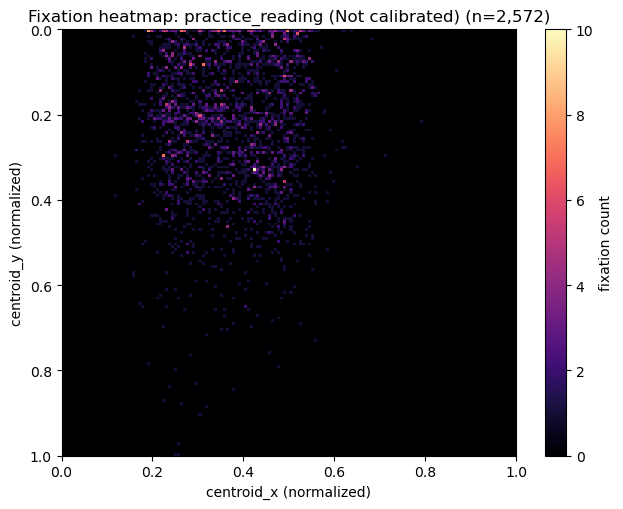

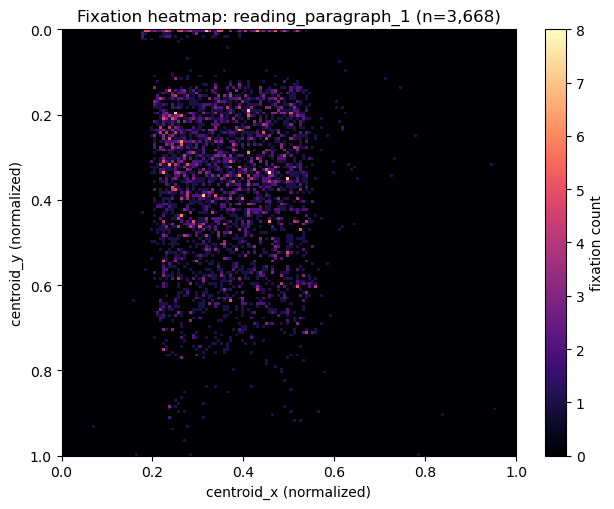

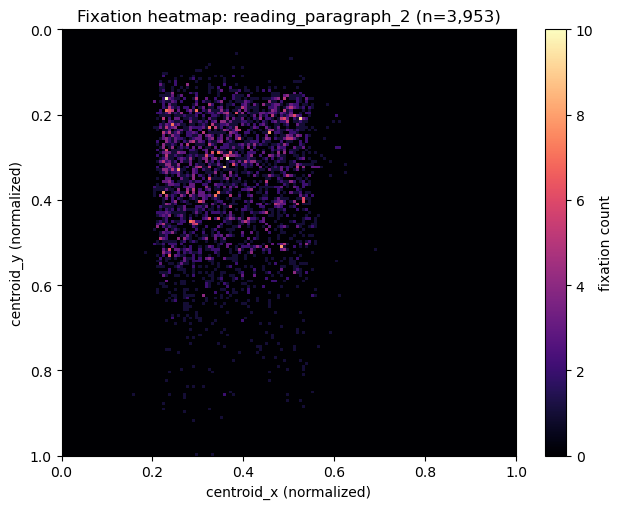

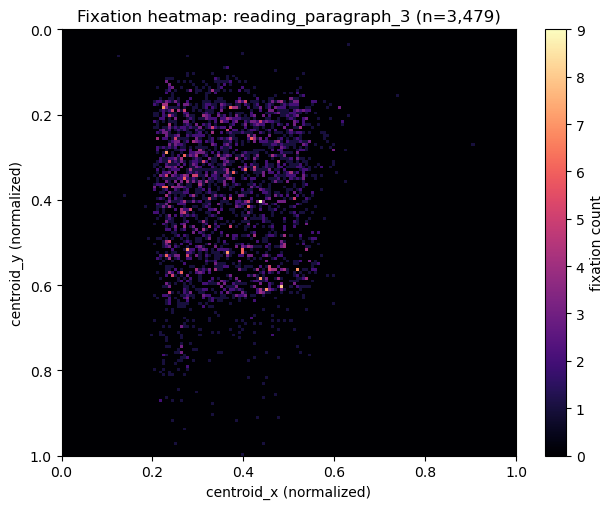

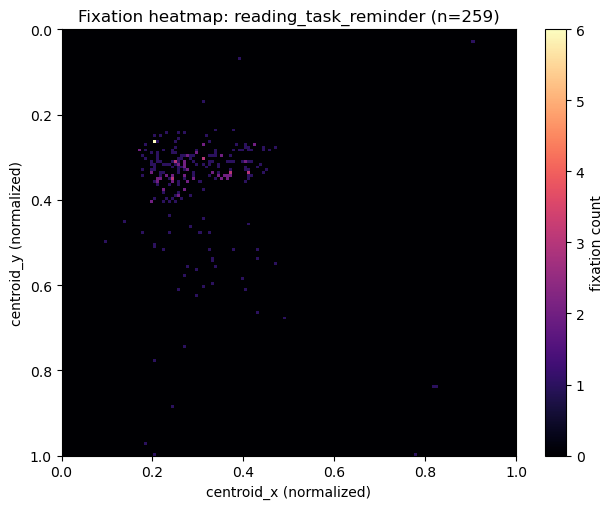

In [49]:
from collections import defaultdict

# expected output from ParticipantTest.py _write_eye_events_csv()
# Centroids are raw NDC coordinates from Tobii: (0,0) at top-left, x increases right, y increases down
required_cols = {
    "section",
    "phase",
    "window_label",
    "event_type",
    "centroid_x",
    "centroid_y",
    "condition",
    "duration_ms",
    "amplitude_ndc",
    "peak_velocity_ndc_per_s",
    "mean_velocity_ndc_per_s",
}
files = glob.glob(os.path.join("..", "logs", "**", "eye_events.csv"), recursive=True)

if not files:
    raise FileNotFoundError(
        "No eye_events.csv files found under ../logs/. Run ParticipantTest sessions first.",
    )

MIN_POINTS_PER_HEATMAP = 50  

def _normalize_label(val):
    if val is None:
        return ""
    s = str(val).strip()
    if not s or s.lower() in {"nan", "none"}:
        return ""
    return s

def _infer_category(section, phase, window_label):
    section = _normalize_label(section).lower()
    phase = _normalize_label(phase).lower()
    label = _normalize_label(window_label).lower()

    # Strong section-level grouping for ParticipantTest naming patterns.
    if re.search(r"reading_paragraph_\d+", label):
        return re.search(r"reading_paragraph_\d+", label).group(0)
    if re.search(r"mcq_reading\d+-mcq", label):
        return re.search(r"mcq_reading\d+-mcq", label).group(0)
    if label == "mcq_practice-mcq":
        return "mcq_practice-mcq (Not calibrated)"
    if "practice_reading" in label:
        return "practice_reading (Not calibrated)"

    if "detectability_practice" in label or phase == "practice":
        return "detectability_practice)"
    if re.search(r"eye_all_blocks_\d+_trial_\d+", label) or phase == "all_blocks":
        return "detectability_all_blocks"

    if "reading_task_reminder" in label:
        return "reading_task_reminder"
    if "questionnaire" in label or "questionnaire" in section:
        return "questionnaire"

    # Fall back to structured metadata before raw label.
    if section and phase:
        return f"{section}::{phase}"
    if section:
        return section
    if phase:
        return phase
    if label:
        return label
    return "unknown_window"

# First pass: gather all rows and determine which event type has usable centroids
all_rows = []
valid_counts = defaultdict(int)
total_rows = 0

for file_path in files:
    try:
        df = pd.read_csv(
            file_path,
            usecols=lambda c: c in required_cols,
            low_memory=False,
        )
    except Exception as exc:
        print(f"Skipping unreadable file: {file_path} ({exc})")
        continue

    if not {"event_type", "centroid_x", "centroid_y"}.issubset(df.columns):
        print(f"Skipping file with missing core columns: {file_path}")
        continue

    total_rows += len(df)
    df["event_type"] = df["event_type"].astype(str).str.lower().str.strip()
    df["centroid_x"] = pd.to_numeric(df["centroid_x"], errors="coerce")
    df["centroid_y"] = pd.to_numeric(df["centroid_y"], errors="coerce")
    df = df[np.isfinite(df["centroid_x"]) & np.isfinite(df["centroid_y"]) ]
    df = df[df["centroid_x"].between(0.0, 1.0) & df["centroid_y"].between(0.0, 1.0)]
    if df.empty:
        continue

    for etype, cnt in df["event_type"].value_counts().items():
        valid_counts[etype] += int(cnt)

    all_rows.append(df)

if not all_rows:
    raise RuntimeError(
        "No valid centroid coordinates found in eye_events.csv files.",
    )

combined = pd.concat(all_rows, ignore_index=True)

# Prefer saccades, but automatically fall back to fixations if needed
if valid_counts.get("saccade", 0) > 0:
    event_type_to_plot = "saccade"
elif valid_counts.get("fixation", 0) > 0:
    event_type_to_plot = "fixation"
else:
    event_type_to_plot = max(valid_counts, key=valid_counts.get)

plot_df = combined[combined["event_type"].eq(event_type_to_plot)].copy()
if plot_df.empty:
    raise RuntimeError(
        f"No rows available for event_type='{event_type_to_plot}' after filtering.",
    )

# Derive a categorical grouping (similar to before) but keep raw window labels too
plot_df["category"] = [
    _infer_category(s, p, w)
    for s, p, w in zip(plot_df["section"], plot_df["phase"], plot_df["window_label"])
]
plot_df["window_label_norm"] = plot_df["window_label"].astype(str).str.strip().str.lower()

# Keep only categories with enough points to be interpretable.
counts = plot_df["category"].value_counts()
keep_categories = counts[counts >= MIN_POINTS_PER_HEATMAP].index.tolist()
plot_df = plot_df[plot_df["category"].isin(keep_categories)]

# Build data_by_category as stacked numpy arrays
data_by_category = defaultdict(list)
for cat, grp in plot_df.groupby("category", dropna=False):
    category_name = _normalize_label(cat) or "unknown_window"
    data_by_category[category_name].append(
        grp[["centroid_x", "centroid_y"]].to_numpy(dtype=np.float32)
    )

for category_name in list(data_by_category.keys()):
    data_by_category[category_name] = np.vstack(data_by_category[category_name])

print(f"Found {len(files)} eye_events.csv files")
print(f"Read {total_rows:,} rows total")
print(f"Plotting event type: {event_type_to_plot}")
print(f"Min points per heatmap: {MIN_POINTS_PER_HEATMAP}")
print(f"Categories with heatmaps: {len(data_by_category)}")

# Select categories of interest (MCQ, reading, detectability).
interest_patterns = [
    r"mcq",
    r"reading_paragraph_\d+",
    r"practice_reading",
    r"reading_task_reminder",
    r"detectability",
    r"all_blocks",
]

selected = [
    k for k in sorted(data_by_category.keys())
    if any(re.search(p, k) for p in interest_patterns)
]

# Fallback to all categories if none matched the interest patterns
if not selected:
    selected = sorted(data_by_category.keys())

bins = 150 #change for detail level

# Plot each selected category as its own figure
for category_name in selected:
    pts = data_by_category.get(category_name)
    if pts is None or pts.size == 0:
        continue

    x = pts[:, 0]
    y = 1.0 - pts[:, 1]

    H, xedges, yedges = np.histogram2d(
        y,
        x,
        bins=bins,
        range=[[0.0, 1.0], [0.0, 1.0]],
    )

    plt.figure(figsize=(6.5, 5.2))
    plt.imshow(
        H,
        origin="upper",
        extent=[0.0, 1.0, 0.0, 1.0],
        cmap="magma",
        aspect="auto",
        interpolation="nearest",
    )
    ax = plt.gca()
    ax.set_ylim(0.0, 1.0)
    ax.invert_yaxis()
    plt.colorbar(label=f"{event_type_to_plot} count")
    plt.title(f"{event_type_to_plot.capitalize()} heatmap: {category_name} (n={len(pts):,})")
    plt.xlabel("centroid_x (normalized)")
    plt.ylabel("centroid_y (normalized)")
    plt.tight_layout()
    plt.show()


**Saccade section**

*descriptively saccades count across tasks and conditions

In [50]:
#Load saccade rows from all participant/session eye event logs.
#The CSVs are written by ParticipantTest.py, one row per event
required_saccade_cols = {
    "participant_id",
    "participant_number",
    "session_id",
    "window_label",
    "section",
    "phase",
    "condition",
    "trial_index",
    "event_type",
    "duration_ms",
    "centroid_x",
    "centroid_y",
    "amplitude_ndc",
    "peak_velocity_ndc_per_s",
    "mean_velocity_ndc_per_s",
}

SaccadeFiles = glob.glob(os.path.join("..", "logs", "**", "eye_events.csv"), recursive=True)

if not files:
    raise FileNotFoundError(
        "No eye_events.csv files found under ../logs/. Run ParticipantTest sessions first.",
    )

saccade_rows = []
for file_path in SaccadeFiles:
    try:
        df = pd.read_csv(
            file_path,
            usecols=lambda col: col in required_saccade_cols,
            low_memory=False,
        )
    except Exception as exc:
        print(f"Skipping unreadable file: {file_path} ({exc})")
        continue

    if "event_type" not in df.columns:
        print(f"Skipping file with missing event_type column: {file_path}")
        continue

    df["event_type"] = df["event_type"].astype(str).str.strip().str.lower()
    df = df[df["event_type"].eq("saccade")].copy()
    if df.empty:
        continue

    for numeric_col in [
        "duration_ms",
        "centroid_x",
        "centroid_y",
        "amplitude_ndc",
        "peak_velocity_ndc_per_s",
        "mean_velocity_ndc_per_s",
    ]:
        if numeric_col in df.columns:
            df[numeric_col] = pd.to_numeric(df[numeric_col], errors="coerce")

    if df.empty:
        continue

    saccade_rows.append(df)

if saccade_rows:
    saccade_df = pd.concat(saccade_rows, ignore_index=True)
else:
    saccade_df = pd.DataFrame(columns=sorted(required_saccade_cols))

# Convenience subset used below for the reading-paragraph breakdown.
reading_saccades = saccade_df[
    saccade_df["window_label"].astype(str).str.contains("reading_paragraph", case=False, na=False)
].copy()

#Convenience subset used below for detectability tasks
detectability_saccades = saccade_df[
    saccade_df["window_label"].astype(str).str.contains("eye_all_blocks", case=False, na=False)
].copy()

# Descriptive statistics for saccade count across tasks and conditions
print("=" * 80)
print("SACCADE COUNT ANALYSIS ACROSS TASKS AND CONDITIONS")
print("=" * 80)

# Overall saccade counts
#This should take saccade count total for each condition available in the dataset and print it in console
print("\n1. TOTAL SACCADE COUNT BY CONDITION (All tasks)")
print("-" * 60)
total_by_condition = saccade_df["condition"].value_counts().sort_index()
for condition, count in total_by_condition.items():
    pct = (count / len(saccade_df)) * 100
    print(f"  Condition {condition}: {count:,} saccades ({pct:.1f}%)")
print(f"  TOTAL: {len(saccade_df):,} saccades\n")

#This should print total saccades in reading paragraphs, broken down by condition. Excluding practice (which is always none condition)
print("2. SACCADE COUNT IN READING PARAGRAPHS BY CONDITION")
print("-" * 60)
reading_no_practice = reading_saccades[
    ~reading_saccades["window_label"].astype(str).str.contains("practice", case=False, na=False)
].copy()
reading_by_condition = reading_no_practice["condition"].value_counts().sort_index()
for condition, count in reading_by_condition.items():
    pct = (count / len(reading_no_practice)) * 100
    print(f"  Condition {condition}: {count:,} saccades ({pct:.1f}%)")
print(f"  TOTAL: {len(reading_no_practice):,} saccades\n")

#This should print total saccades in detectability tasks, broken down by condition. Excluding practice (which is always 2,2,2 of each condition)
print("3. SACCADE COUNT IN DETECTABILITY TASKS BY CONDITION")
print("-" * 60)
detectability_no_practice = detectability_saccades[
    ~detectability_saccades["window_label"].astype(str).str.contains("practice", case=False, na=False)
].copy()
detectability_by_condition = detectability_no_practice["condition"].value_counts().sort_index()
for condition, count in detectability_by_condition.items():
    pct = (count / len(detectability_no_practice)) * 100
    print(f"  Condition {condition}: {count:,} saccades ({pct:.1f}%)")
print(f"  TOTAL: {len(detectability_no_practice):,} saccades\n")

SACCADE COUNT ANALYSIS ACROSS TASKS AND CONDITIONS

1. TOTAL SACCADE COUNT BY CONDITION (All tasks)
------------------------------------------------------------
  Condition eyetracked: 11,930 saccades (17.1%)
  Condition full: 8,037 saccades (11.5%)
  Condition none: 49,867 saccades (71.4%)
  TOTAL: 69,834 saccades

2. SACCADE COUNT IN READING PARAGRAPHS BY CONDITION
------------------------------------------------------------
  Condition eyetracked: 9,995 saccades (44.7%)
  Condition full: 6,222 saccades (27.8%)
  Condition none: 6,154 saccades (27.5%)
  TOTAL: 22,371 saccades

3. SACCADE COUNT IN DETECTABILITY TASKS BY CONDITION
------------------------------------------------------------
  Condition eyetracked: 1,686 saccades (34.9%)
  Condition full: 1,577 saccades (32.7%)
  Condition none: 1,565 saccades (32.4%)
  TOTAL: 4,828 saccades



*Graph saccade duration and magnitude grouped by each condition*

MAIN SEQUENCE ANALYSIS: SACCADE DIAGNOSTICS

READING TASK:


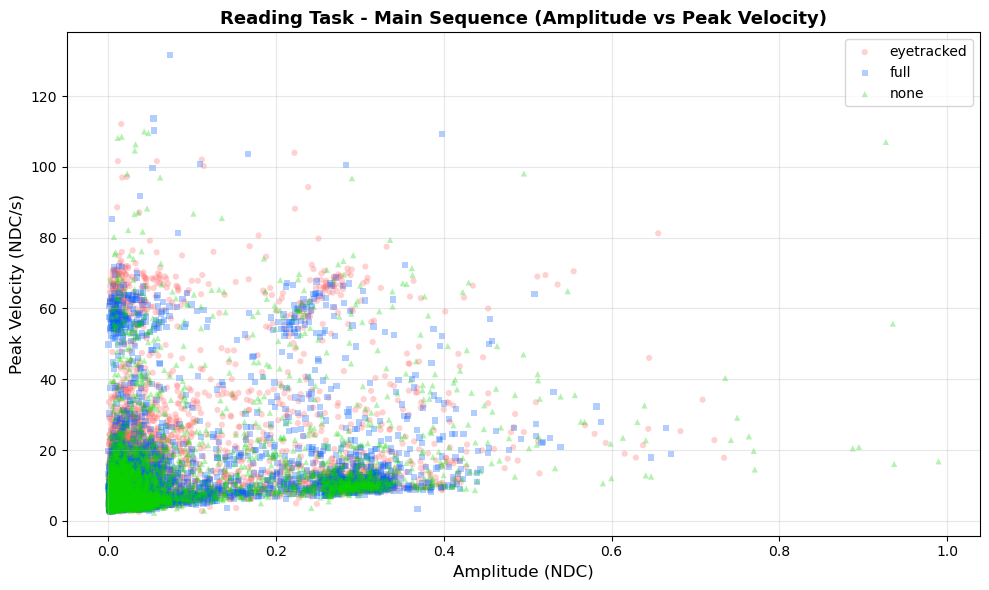

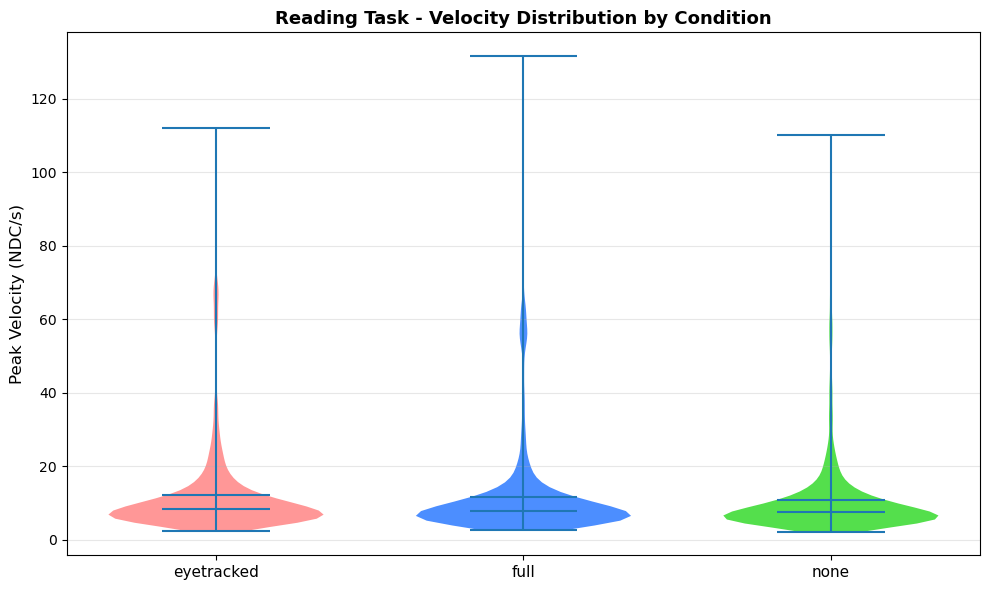

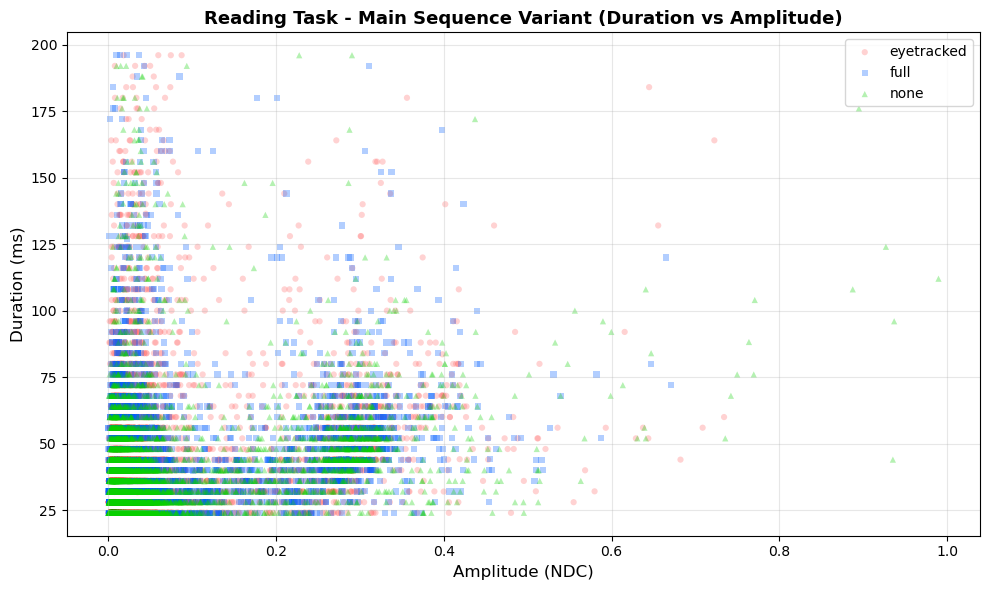


Reading Task Statistics:
  eyetracked: n=9995, amp=0.0473±0.0845, vel=12.1633±12.2172, dur=39.28±21.37ms
  full: n=6222, amp=0.0556±0.0934, vel=11.5972±12.3445, dur=38.54±20.74ms
  none: n=6154, amp=0.0594±0.1037, vel=10.9591±11.3947, dur=37.75±19.84ms

DETECTABILITY TASK:


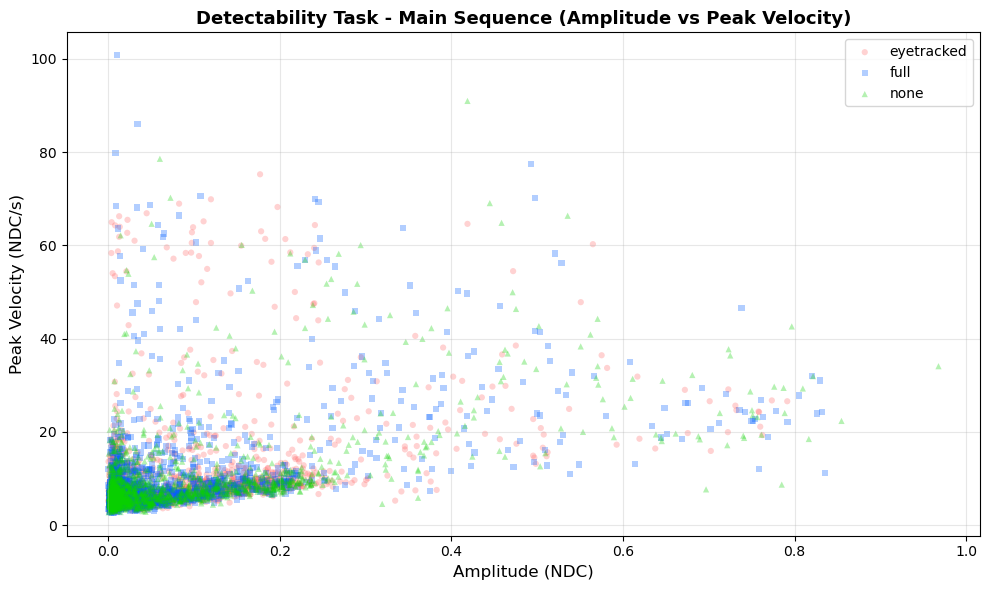

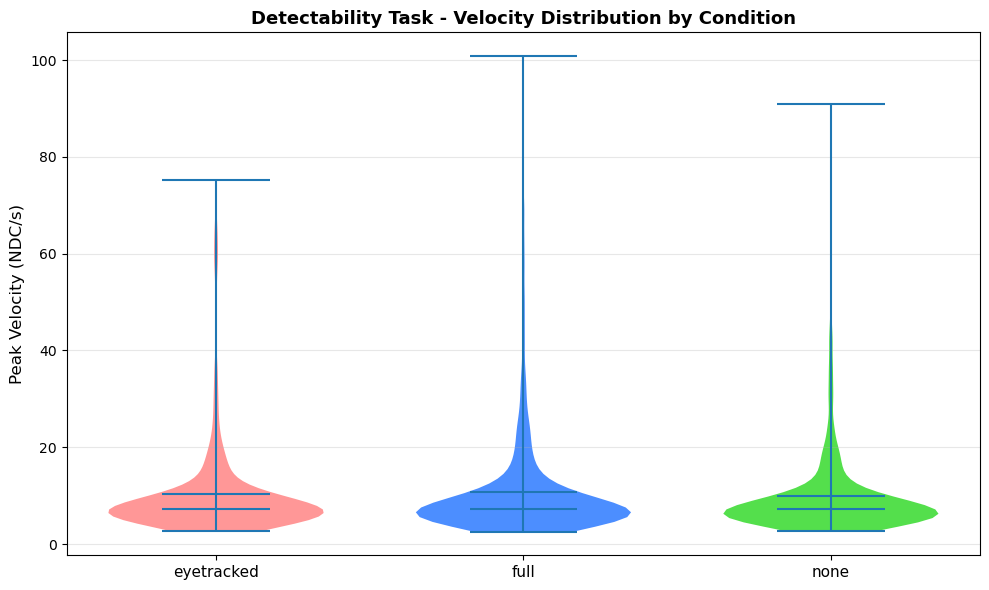

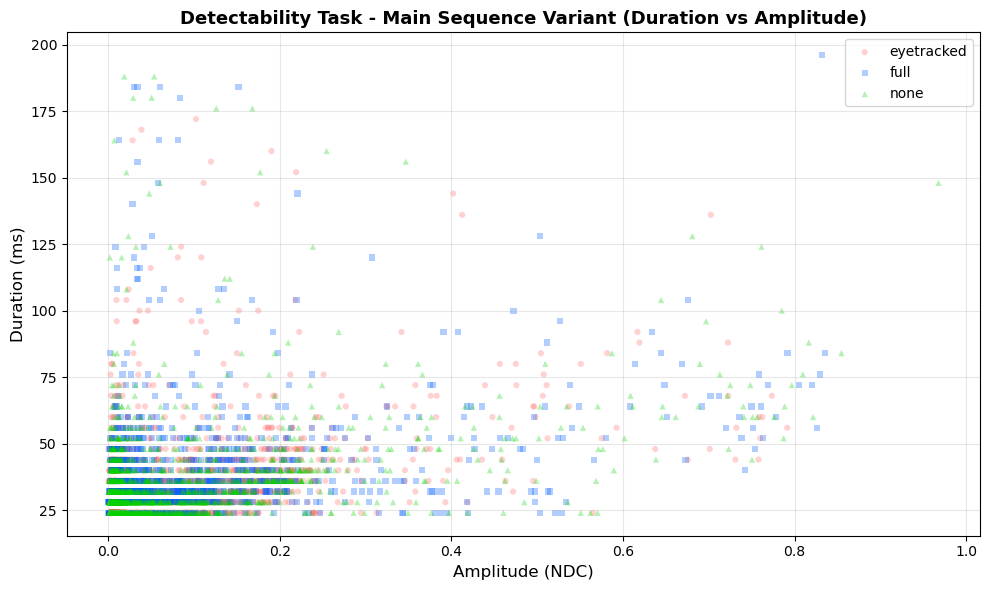


Detectability Task Statistics:
  eyetracked: n=1686, amp=0.0876±0.1151, vel=10.4496±10.3875, dur=35.64±16.69ms
  full: n=1577, amp=0.0842±0.1363, vel=10.7359±10.7895, dur=36.61±19.55ms
  none: n=1565, amp=0.0909±0.1402, vel=9.8903±9.1892, dur=35.98±18.85ms



In [51]:
# Saccade main sequence diagnostics: amplitude, velocity, duration analysis
print("=" * 80)
print("MAIN SEQUENCE ANALYSIS: SACCADE DIAGNOSTICS")
print("=" * 80)

# Define conditions and markers for clear distinction
conditions = ["eyetracked", "full", "none"]
colors_dict = {"eyetracked": "#FF6B6B", "full": "#005EFF", "none": "#0BD20092"}
markers_dict = {"eyetracked": "o", "full": "s", "none": "^"}

# ============================================================================
# READING TASK ANALYSIS - 3 separate plots
# ============================================================================
print("\nREADING TASK:")

# Plot 1: Main Sequence (Amplitude vs Peak Velocity)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
for condition in conditions:
    data = reading_no_practice[reading_no_practice["condition"] == condition]
    amp = data["amplitude_ndc"].dropna()
    vel = data["peak_velocity_ndc_per_s"].dropna()
    ax.scatter(amp, vel, alpha=0.3, s=20, color=colors_dict[condition], 
               marker=markers_dict[condition], label=condition, edgecolors="none")

ax.set_xlabel("Amplitude (NDC)", fontsize=12)
ax.set_ylabel("Peak Velocity (NDC/s)", fontsize=12)
ax.set_title("Reading Task - Main Sequence (Amplitude vs Peak Velocity)", fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Velocity Distribution - violin plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
violin_data = [reading_no_practice[reading_no_practice["condition"] == c]["peak_velocity_ndc_per_s"].dropna().values 
               for c in conditions]
parts = ax.violinplot(violin_data, positions=range(len(conditions)), widths=0.7, showmeans=True, showmedians=True)

# Color the violin plots
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(colors_dict[conditions[i]])
    pc.set_alpha(0.7)

ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, fontsize=11)
ax.set_ylabel("Peak Velocity (NDC/s)", fontsize=12)
ax.set_title("Reading Task - Velocity Distribution by Condition", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Plot 3: Duration vs Amplitude
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
for condition in conditions:
    data = reading_no_practice[reading_no_practice["condition"] == condition]
    amp = data["amplitude_ndc"].dropna()
    dur = data["duration_ms"].dropna()
    ax.scatter(amp, dur, alpha=0.3, s=20, color=colors_dict[condition], 
               marker=markers_dict[condition], label=condition, edgecolors="none")

ax.set_xlabel("Amplitude (NDC)", fontsize=12)
ax.set_ylabel("Duration (ms)", fontsize=12)
ax.set_title("Reading Task - Main Sequence Variant (Duration vs Amplitude)", fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics for reading task
print("\nReading Task Statistics:")
for condition in conditions:
    data = reading_no_practice[reading_no_practice["condition"] == condition]
    amp = data["amplitude_ndc"].dropna()
    vel = data["peak_velocity_ndc_per_s"].dropna()
    dur = data["duration_ms"].dropna()
    print(f"  {condition}: n={len(data)}, amp={amp.mean():.4f}±{amp.std():.4f}, vel={vel.mean():.4f}±{vel.std():.4f}, dur={dur.mean():.2f}±{dur.std():.2f}ms")

# ============================================================================
# DETECTABILITY TASK ANALYSIS - 3 separate plots
# ============================================================================
print("\n" + "=" * 80)
print("DETECTABILITY TASK:")

# Plot 1: Main Sequence (Amplitude vs Peak Velocity)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
for condition in conditions:
    data = detectability_no_practice[detectability_no_practice["condition"] == condition]
    amp = data["amplitude_ndc"].dropna()
    vel = data["peak_velocity_ndc_per_s"].dropna()
    ax.scatter(amp, vel, alpha=0.3, s=20, color=colors_dict[condition], 
               marker=markers_dict[condition], label=condition, edgecolors="none")

ax.set_xlabel("Amplitude (NDC)", fontsize=12)
ax.set_ylabel("Peak Velocity (NDC/s)", fontsize=12)
ax.set_title("Detectability Task - Main Sequence (Amplitude vs Peak Velocity)", fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Velocity Distribution - violin plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
violin_data = [detectability_no_practice[detectability_no_practice["condition"] == c]["peak_velocity_ndc_per_s"].dropna().values 
               for c in conditions]
parts = ax.violinplot(violin_data, positions=range(len(conditions)), widths=0.7, showmeans=True, showmedians=True)

# Color the violin plots
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(colors_dict[conditions[i]])
    pc.set_alpha(0.7)

ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, fontsize=11)
ax.set_ylabel("Peak Velocity (NDC/s)", fontsize=12)
ax.set_title("Detectability Task - Velocity Distribution by Condition", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Plot 3: Duration vs Amplitude
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
for condition in conditions:
    data = detectability_no_practice[detectability_no_practice["condition"] == condition]
    amp = data["amplitude_ndc"].dropna()
    dur = data["duration_ms"].dropna()
    ax.scatter(amp, dur, alpha=0.3, s=20, color=colors_dict[condition], 
               marker=markers_dict[condition], label=condition, edgecolors="none")

ax.set_xlabel("Amplitude (NDC)", fontsize=12)
ax.set_ylabel("Duration (ms)", fontsize=12)
ax.set_title("Detectability Task - Main Sequence Variant (Duration vs Amplitude)", fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics for detectability task
print("\nDetectability Task Statistics:")
for condition in conditions:
    data = detectability_no_practice[detectability_no_practice["condition"] == condition]
    amp = data["amplitude_ndc"].dropna()
    vel = data["peak_velocity_ndc_per_s"].dropna()
    dur = data["duration_ms"].dropna()
    print(f"  {condition}: n={len(data)}, amp={amp.mean():.4f}±{amp.std():.4f}, vel={vel.mean():.4f}±{vel.std():.4f}, dur={dur.mean():.2f}±{dur.std():.2f}ms")

print("\n" + "=" * 80)